# MiniBatch K-Means - H&M (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    minibatch_kmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/hym_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["customer_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 1,362,281
Variables de clustering: 3


,recency,frequency,monetary
0,-1.216313,0.926194,0.765377
1,-0.614156,1.811026,1.771317
2,-1.404203,0.565013,0.847795
3,1.106440,-1.007279,-1.056769
4,-0.918963,0.413566,0.433500


## Evaluación del número de clusters


In [3]:
resultados_minibatch = minibatch_kmeans_metrics(X)
display(resultados_minibatch)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos
0,2,0.499415,1.964706e+06,0.754819,1.673729e+06,1.870814
1,3,0.414013,1.786461e+06,0.898736,1.128208e+06,0.916977
2,4,0.383756,1.718468e+06,0.924096,8.544779e+05,0.945757
3,5,0.386034,1.622377e+06,0.916209,7.098676e+05,5.031502
4,6,0.337815,1.515566e+06,0.978771,6.229999e+05,4.374992
5,7,0.339531,1.431265e+06,0.986502,5.601354e+05,5.937371
6,8,0.280340,1.285136e+06,1.165555,5.389841e+05,5.262031
7,9,0.317993,1.351439e+06,0.994983,4.581064e+05,5.030874
8,10,0.289247,1.277828e+06,1.078650,4.334820e+05,4.454030


In [4]:
tabla_metricas = save_clustering_metrics(
    resultados_minibatch,
    model_name="minibatch",
    dataset_name="hym",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


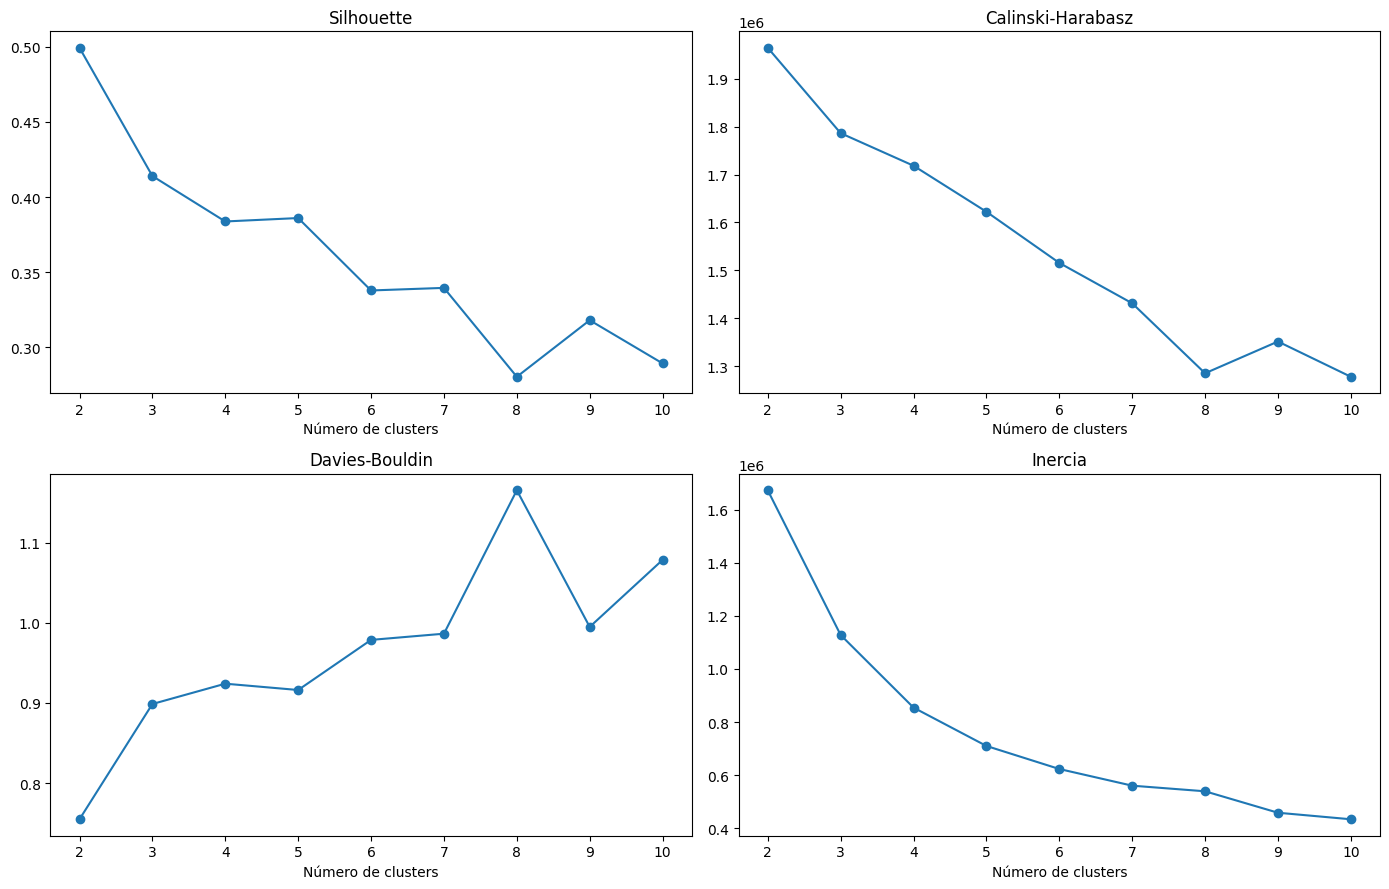

In [5]:
plot_clustering_metrics(
    resultados_minibatch,
    fourth_metric="inertia",
    fourth_title="Inercia",
)

In [6]:
k_recomendado = int(resultados_minibatch.loc[resultados_minibatch["silhouette"].idxmax(), "k"] )
print(f"k recomendado según silhouette: {k_recomendado}")

k recomendado según silhouette: 2


## Ajuste final y perfil de los clusters


In [7]:
modelo, labels = fit_clustering_model(
    model_name="minibatch",
    k=k_recomendado,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="customer_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    817604
1    544677
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    60.02
1    39.98
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,monetary
cluster,,,
0,342.322,1.887,0.152
1,76.773,13.838,1.396


- Cluster 0 - Clientes ocasionales o inactivos (60,02%): presentan una recencia muy elevada, menos de dos compras y un gasto reducido.
- Cluster 1 - Clientes frecuentes y de alto valor (39,98%): muestran baja recencia, cerca de catorce compras y un gasto muy superior, por lo que constituyen el segmento más valioso.